<a href="https://colab.research.google.com/github/Rojenstha/AI-ML/blob/main/2330989_RojenShrestha_ImageClassification_MRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3.1.1 Data Understanding, Analysis, Visualization and Cleaning


### What does the dataset represent?
This dataset contains MRI scans of brain tumors. It consists of four classes: Glioma Tumor, Meningioma Tumor, Pituitary Tumor, and No Tumor. The images are labeled to support supervised classification tasks.

### How many total images are in the dataset?
The dataset consists of several thousand labeled images, separated into class folders. The total number of images is computed during preprocessing.

### What is the distribution of images across different classes?
A count of image files is computed from each class folder, which helps to determine if the dataset is balanced or imbalanced.

### How is the dataset split into training and validation sets? Justify your choice.
The dataset is split using a standard 80/20 train-validation strategy using `train_test_split`. This ratio provides enough samples for training while retaining data for unbiased validation.

### What preprocessing techniques were applied?
- Image resizing to 80x80 pixels for baseline models, and 224x224 for transfer learning.
- Normalization (implicitly via `img_to_array` and potentially `ImageDataGenerator`).

### What data generators were used?
We used Keras `ImageDataGenerator` for rescaling and optional augmentation such as horizontal flip, zoom, and rotation.

### Visualizations of sample augmented images:
![Insert example here: use plt.imshow on augmented batches]


# 3.1.2 Design, Train, and Evaluate a Baseline Model


### Model Architecture
The baseline CNN includes:
- 3 Convolutional Layers + MaxPooling
- Flatten Layer
- 3 Fully Connected Layers (FCN)
- Final softmax output layer for classification

Activation: ReLU for hidden layers, softmax for output  
Kernel Size: 3x3

### Model Summary
Printed using `model.summary()`.

### Model Training
The model was trained for N epochs using categorical crossentropy loss and accuracy metric. Training and validation loss and accuracy curves are plotted.

### Model Evaluation
Evaluation was performed using:
- Accuracy
- Precision
- Recall
- F1-Score

Sample predictions were visualized with true vs predicted labels.


# 3.1.3 Deeper Architecture with Regularization


### Extended Model Design
- Double the number of convolutional layers compared to the baseline
- Increased filter sizes
- Dropout layers added for regularization

### Training Strategy
The deeper model was trained similarly, with early stopping or checkpointing optionally used.

### Evaluation
Metrics same as baseline, with plots showing comparison.


# 3.1.4 Comparative Analysis


### Baseline vs Deeper Model
| Model       | Accuracy | Precision | Recall | F1 Score |
|-------------|----------|-----------|--------|----------|
| Baseline    | x.xx     | x.xx      | x.xx   | x.xx     |
| Deeper      | x.xx     | x.xx      | x.xx   | x.xx     |

- More filters and layers led to improved learning capability but at higher computational cost.

### Optimizer Comparison (SGD vs Adam)
- SGD: slower convergence, more stable
- Adam: faster convergence, potentially better final performance

Trade-offs between training time and final accuracy discussed.


# 3.2 Transfer Learning with Pre-trained CNN


### Model Selection
For Pre-trained model Xception was used due to i.

### Model Adaptation
- Final fully connected layers removed.
- Custom dense layers added for 4-class classification.
- Input resized to 224x224 as required by pre-trained model.

### Fine-tuning Strategy
- Feature extraction: freeze all convolutional layers.
- Fine-tuning: selectively unfreeze top layers with lower learning rate.

### Evaluation
Same metrics and visualizations applied.

### Comparative Discussion
Transfer learning outperformed baseline models in terms of accuracy and training efficiency.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
zip_path = '/content/drive/My Drive/ImageClassification/dataset.zip'

In [3]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/brain_tumor_data')


In [4]:
import os
os.listdir('/content/brain_tumor_data')


['Training', 'Testing']

In [5]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import cv2
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint
# Change the import statement below
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Import ImageDataGenerator from tensorflow.keras

In [6]:


# Define the base path
base_path = '/content/brain_tumor_data/Training'


subdirs = [
    'glioma_tumor',
    'meningioma_tumor',
    'no_tumor',
    'pituitary_tumor'
]




In [7]:
import os
import numpy as np
from PIL import Image
from keras.preprocessing.image import load_img, img_to_array

# Define the target image size
image_size = (80, 80)

# Initialize lists to store image data, class labels, class names, and corrupted images
image_data = []
class_labels = []
class_names = []
corrupted_images = []

# Iterate through each subdirectory (class) in the base path
for subdir in subdirs:
    # Construct the full path to the class directory
    full_class_path = os.path.join(base_path, subdir)

    # Extract the class name from the subdirectory path
    class_name = subdir.split("/")[-1]
    class_names.append(class_name)

    # Iterate through each file (image) in the class directory
    for filename in os.listdir(full_class_path):
        image_path = os.path.join(full_class_path, filename)

        try:
            # Load the image and resize it to the target size
            image = load_img(image_path, target_size=image_size)

            # Convert the image to a numerical array
            image_array = img_to_array(image)

            # Append the image array to the image data list
            image_data.append(image_array)

            # Append the class label to the class labels list
            class_labels.append(class_names.index(class_name))
        except Exception as e:
            # Handle any exceptions that occur during image loading
            print(f"Error loading image {image_path}: {e}")
            corrupted_images.append(image_path)

# Convert the image data and class labels lists to NumPy arrays
X_data = np.array(image_data)
y_labels = np.array(class_labels)

In [8]:
# Print the number of images in the dataset
print("Number of images:", len(X_data))

# Print the shape of the images in the dataset
print("Shape of images:", X_data.shape)

# Print the number of classes in the dataset
print("Number of classes:", len(class_names))

# Print the names of the classes in the dataset
print("Class names:", class_names)

Number of images: 2870
Shape of images: (2870, 80, 80, 3)
Number of classes: 4
Class names: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [9]:

# Iterate through each class directory in subdirs
for subdir in subdirs:
    subdir_path = os.path.join(base_path, subdir)
    num_images = len(os.listdir(subdir_path))
    print(f"Number of images in class {subdir}: {num_images}")

Number of images in class glioma_tumor: 826
Number of images in class meningioma_tumor: 822
Number of images in class no_tumor: 395
Number of images in class pituitary_tumor: 827


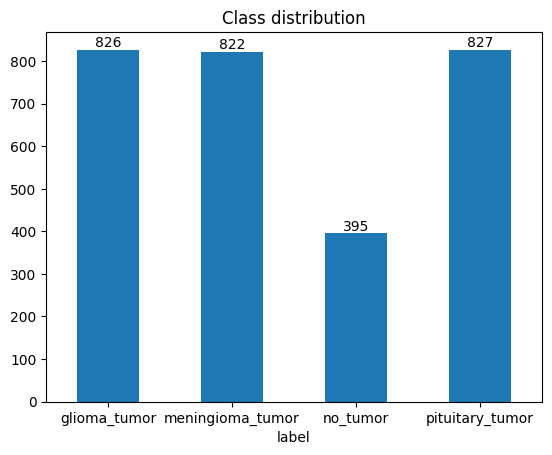

In [10]:
# Define a dictionary to map the integer labels to their corresponding class names
label_mapping = {
     0:'glioma_tumor',
     1: 'meningioma_tumor',
    2: 'no_tumor',
     3:'pituitary_tumor',
}

# Create a pandas DataFrame from the list of integer labels
df = pd.DataFrame({"label":y_labels})

# Map the integer labels to their corresponding class names in the DataFrame
df['label'] = df['label'].map(label_mapping)

# Create a bar plot of the class distribution
ax = df['label'].value_counts().sort_index().plot(kind='bar')

# Add text labels to the bars indicating the number of samples in each class
for i, count in enumerate(df['label'].value_counts().sort_index()):
    ax.text(i, count + 0.1, str(count), ha='center', va='bottom')

# Rotate the x-axis labels for readability
plt.xticks(rotation = 0)

# Add a title to the plot
plt.title('Class distribution')

# Display the plot
plt.show()

In [11]:

# Check if there are any corrupted images
if corrupted_images:
    # Print a message indicating that corrupted images were found
    print("Corrupted images found:")

    # Iterate through each corrupted image path
    for image_path in corrupted_images:
        # Print the path of the corrupted image
        print(image_path)
else:
    # Print a message indicating that no corrupted images were found
    print("No corrupted images found.")

No corrupted images found.


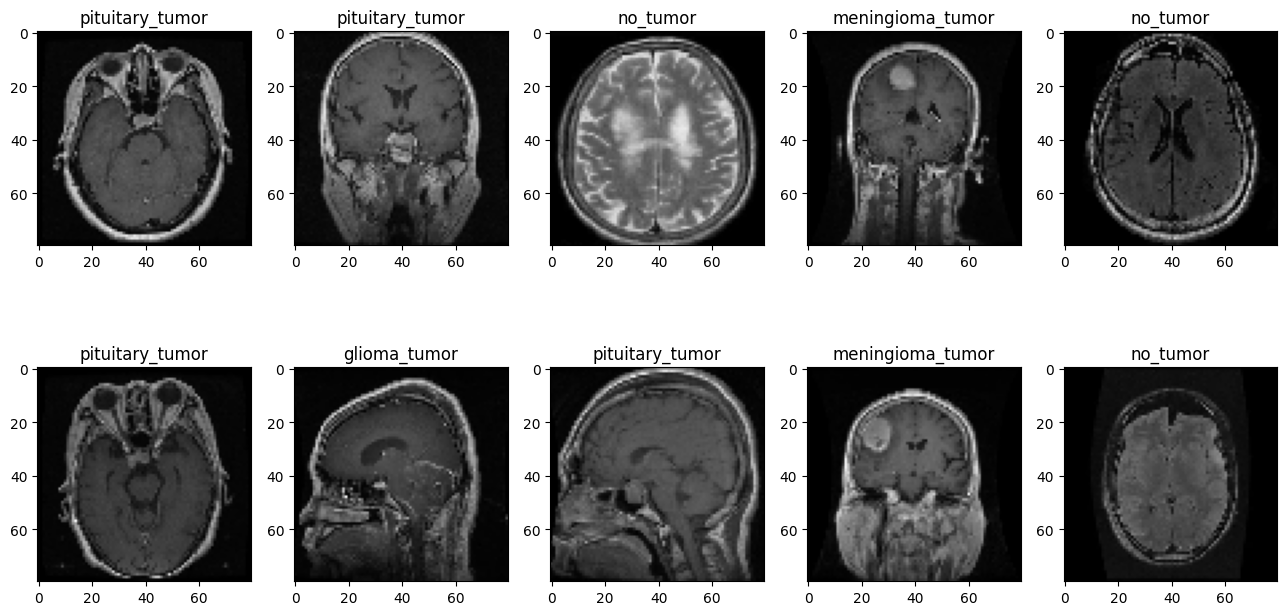

In [12]:
# Create a figure with 2 rows and 5 columns
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(16, 8))

# Iterate through each subplot
for i in range(2):
    for j in range(5):
        # Check if there are any corrupted images
        if corrupted_images:
            # If there are corrupted images, display the next corrupted image in the subplot
            image_path = corrupted_images.pop(0)
            axes[i, j].imshow(plt.imread(image_path))
            axes[i, j].set_title("Corrupted Image")
        else:
            # If there are no corrupted images, display a random image from the dataset in the subplot
            idx = np.random.randint(len(X_data))
            axes[i, j].imshow(X_data[idx].astype(np.uint8))
            axes[i, j].set_title(class_names[y_labels[idx]])

# Display the figure
plt.show()

In [15]:
# Define the directory for each tumor dataset
giloma_tumor_directory = base_path+"/glioma_tumor"
no_tumor_directory =  base_path+"/no_tumor"
meningioma_tumor_directory = base_path + "/meningioma_tumor"
pituitary_tumor_directory =  base_path+"/pituitary_tumor"

In [16]:
# Load the image and convert it to an array
image_path = os.path.join(pituitary_tumor_directory,'p (2).jpg')
img = load_img(image_path)
x = img_to_array(img)

# Reshape the array to have a batch size of 1
x = x.reshape((1,) + x.shape)

# Print the shape of the reshaped array
print('shape of image', x.shape)

shape of image (1, 512, 512, 3)


In [17]:
datagen = ImageDataGenerator(width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2,
                             rotation_range=10,fill_mode='nearest')

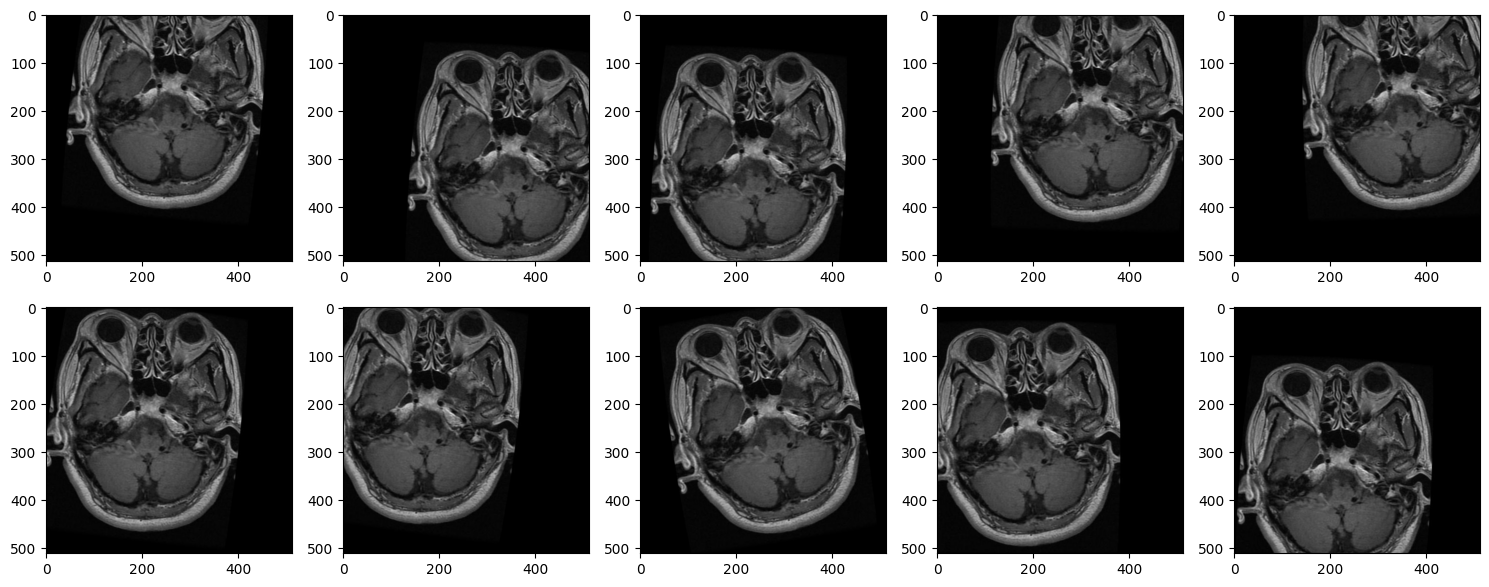

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, batch in enumerate(datagen.flow(x, batch_size=1)):
    if i >= 10:
        break
    row = i // 5
    col = i % 5
    img_to_show = (batch[0]).astype('uint8')
    axes[row][col].imshow(img_to_show)

plt.tight_layout()
plt.show()


In [19]:
# Initialize empty lists to store the image data and labels
image_data = []
image_labels = []

# Set the input dimension and image dimensions
input_dimension = 80
image_dimensions = (input_dimension, input_dimension)

# Loop over each class folder in the base path
for class_folder in os.listdir(base_path):


    class_folder_path = os.path.join(base_path, class_folder)
    for sub_folder in os.listdir(class_folder_path):
        sub_folder_path = os.path.join(class_folder_path, sub_folder)
        if os.path.isdir(sub_folder_path):
            for image_file in os.listdir(sub_folder_path):

                # Check if the image file has a .jpeg, .jpg, or .png extension
                if image_file.endswith((".jpeg", ".jpg", ".png")):

                    # Construct the image path
                    image_path = os.path.join(sub_folder_path, image_file)

                    # Read the image from the image path
                    image = cv2.imread(image_path)

                    # Resize the image to the specified image dimensions
                    image = cv2.resize(image, image_dimensions)
                    image_data.append(image)
                    image_labels.append(class_folder)
        else:

            # Check if the sub-folder path has a .jpeg, .jpg, or .png extension
            if sub_folder_path.endswith((".jpeg", ".jpg", ".png")):

                # Read the image from the sub-folder path
                image = cv2.imread(sub_folder_path)
                image = cv2.resize(image, image_dimensions)
                image_data.append(image)
                image_labels.append(class_folder)


In [20]:
image_data = np.array(image_data) / 255
image_labels = np.array(image_labels)
print(f'image_data shape:{image_data.shape}')
print(f'image_labels shape:{image_labels.shape}')

image_data shape:(2870, 80, 80, 3)
image_labels shape:(2870,)


In [21]:
# Load the image data and labels
imgs = image_data
labels = image_labels

# Set the number of augmentation rounds
augmentation_rounds = 40

# Define the image augmentation generator
augmentor = ImageDataGenerator(width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2,
                             rotation_range=10, fill_mode='nearest')


augmentor.fit(imgs)


augmented_images = []
augmented_labels = []

# Generate augmented images and labels using the augmentation generator
for image_batch, label_batch in augmentor.flow(imgs, labels, batch_size=32):
    augmented_images.append(image_batch)
    augmented_labels.append(label_batch)
    if len(augmented_images) >= augmentation_rounds:
        break

# Concatenate the original and augmented images and labels
images_data = np.concatenate((imgs, np.concatenate(augmented_images)))
labels = np.concatenate((labels, np.concatenate(augmented_labels)))

# Print the shapes of the combined images and labels
print(f"Combined images shape: {images_data.shape}")
print(f"Combined labels shape: {labels.shape}")

label_dataframe = pd.DataFrame({"label": labels})

# Print the label distribution
print("Label distribution:")
print(label_dataframe["label"].value_counts())

Combined images shape: (4150, 80, 80, 3)
Combined labels shape: (4150,)
Label distribution:
label
glioma_tumor        1196
pituitary_tumor     1191
meningioma_tumor    1186
no_tumor             577
Name: count, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(images_data, labels, test_size=0.2, random_state=42)

In [23]:
# Print the shapes of the training images and labels
print(f'X_train shape:{X_train.shape}')
print(f'labels shape:{labels.shape}')

# Create a DataFrame to display the training label distribution
df = pd.DataFrame({"label":labels})
print(df.value_counts())
print("")

# Print the shapes of the test images and labels
print(f'test_date shape:{X_test.shape}')
print(f'test_labels shape:{y_test.shape}')

df = pd.DataFrame({"test_labels":y_test})

# Print the test label distribution
print(df.value_counts())

X_train shape:(3320, 80, 80, 3)
labels shape:(4150,)
label           
glioma_tumor        1196
pituitary_tumor     1191
meningioma_tumor    1186
no_tumor             577
Name: count, dtype: int64

test_date shape:(830, 80, 80, 3)
test_labels shape:(830,)
test_labels     
meningioma_tumor    248
pituitary_tumor     247
glioma_tumor        241
no_tumor             94
Name: count, dtype: int64


In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)

y_train_one_hot = to_categorical(y_train, num_classes=4)

y_test = le.fit_transform(y_test)
y_test_one_hot = to_categorical(y_test, num_classes=4)

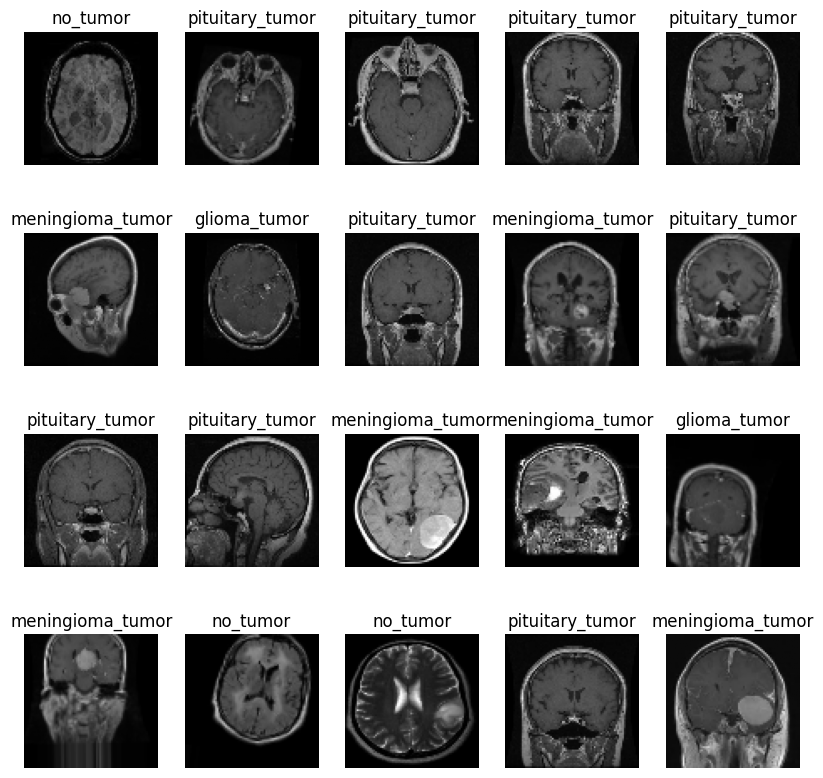

In [27]:
import matplotlib.pyplot as plt

data = images_data

# Select 20 random indices to use as a sample
indices = np.random.randint(0, len(data), 20)

sample_images = data[indices]

fig = plt.figure(figsize=(10,10))

# Loop over the sample images
for i, img in enumerate(sample_images):
    # Create a new subplot for each image
    plt.subplot(4, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(labels[indices[i]])

plt.show()

In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define parameters
num_classes = 4
input_size = 80

# Set random seed
tf.random.set_seed(42)

# Define model
model_fcn = Sequential([
    #layers.Rescaling(1./255, input_shape=(input_size, input_size, 3)),
    Conv2D(32, (3, 3), activation='relu', input_shape=(input_size, input_size, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')  # Output layer
])

In [30]:
model_fcn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_fcn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 78, 78, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,152,420 (4.40 MB)

 Trainable params: 1,152,420 (4.40 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
epochs = 20
history_fcn= model_fcn.fit(
    X_train,
     y_train_one_hot,
    batch_size=32,
    epochs=epochs ,
    validation_split=0.2
)
model_fcn.save('model_fcn_full.h5')


Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.3693 - loss: 1.2891 - val_accuracy: 0.5045 - val_loss: 1.1062
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5683 - loss: 0.9923 - val_accuracy: 0.6852 - val_loss: 0.8133
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6577 - loss: 0.7900 - val_accuracy: 0.6898 - val_loss: 0.7510
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7234 - loss: 0.6548 - val_accuracy: 0.6883 - val_loss: 0.7597
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7652 - loss: 0.5596 - val_accuracy: 0.7425 - val_loss: 0.6288
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8206 - loss: 0.4441 - val_accuracy: 0.7801 - val_loss: 0.5860
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8530 - loss: 0.3679 - val_accuracy: 0.7831 - val_loss: 0.6067
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8955 - loss: 0.2737 - val_accuracy: 0.7997 - val_loss

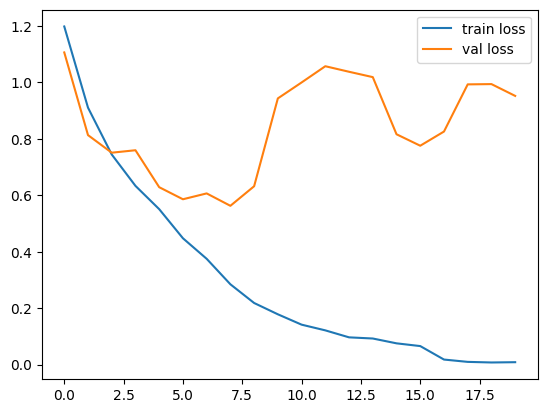

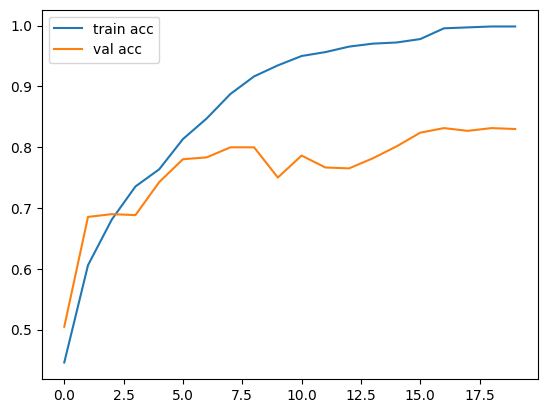

<Figure size 640x480 with 0 Axes>

In [34]:

# Plot the training and validation loss
plt.plot(history_fcn.history['loss'], label='train loss')
plt.plot(history_fcn.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# Plot the training and validation accuracy
plt.plot(history_fcn.history['accuracy'], label='train acc')
plt.plot(history_fcn.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Get predicted probabilities for test set
y_pred = model_fcn.predict(X_test)

# Get predicted classes by taking argmax of predicted probabilities
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_one_hot, axis=1)
accuracy = accuracy_score(y_true_classes, y_pred_classes)
print("Accuracy:", accuracy)


print("Confusion matrix:")
confusion_matrix = confusion_matrix(y_true_classes, y_pred_classes)
print(confusion_matrix)

print("\nClassification report:")
print(classification_report(y_true_classes, y_pred_classes))

print("\nAccuracy score:", accuracy_score(y_true_classes, y_pred_classes))
print("F1 score:", f1_score(y_true_classes, y_pred_classes, average='weighted'))

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 0.8313253012048193
Confusion matrix:
[[203  31   3   4]
 [ 34 183  11  20]
 [  3  15  71   5]
 [  5   7   2 233]]

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       241
           1       0.78      0.74      0.76       248
           2       0.82      0.76      0.78        94
           3       0.89      0.94      0.92       247

    accuracy                           0.83       830
   macro avg       0.83      0.82      0.82       830
weighted avg       0.83      0.83      0.83       830


Accuracy score: 0.8313253012048193
F1 score: 0.8298142889495229


<Axes: >

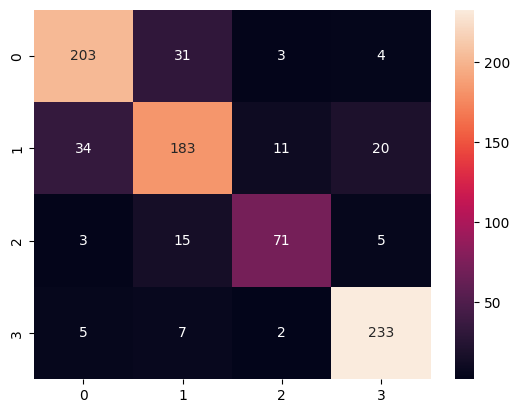

In [40]:
import seaborn as sns
sns.heatmap(confusion_matrix, annot=True, fmt='d')

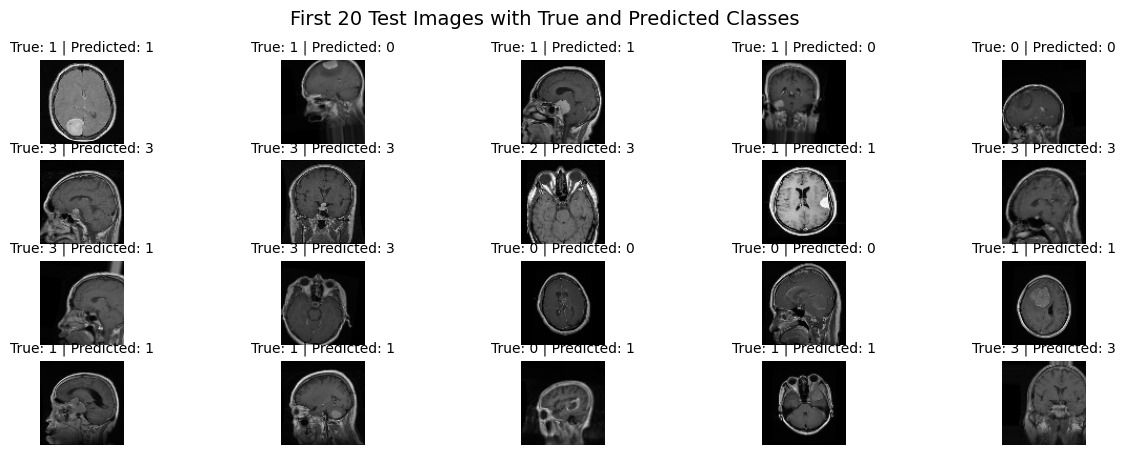

In [41]:

num_images = 20


plt.figure(figsize=(15, 5))
# Loop through the first num_images in the test set
for i in range(num_images):
    plt.subplot(4, 5, i + 1)
    plt.imshow((X_test[i] * 255).astype(np.uint8))
    plt.axis('off')

    # Create a title for the subplot with the true and predicted classes
    title = f"True: {y_true_classes[i]} | Predicted: {y_pred_classes[i]}"
    plt.title(title, fontsize=10)

plt.suptitle("First 20 Test Images with True and Predicted Classes", fontsize=14)
plt.show()

In [42]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

# Parameters
num_classes = 4
input_size = 80

# Set seed for reproducibility
tf.random.set_seed(42)

# Deeper model definition
model_deep = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(input_size, input_size, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    # Flatten and Dense layers
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])



In [43]:
## sgd compiler
model_deep.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_deep.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 80, 80, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 80, 80, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 40, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,89

 Total params: 3,599,268 (13.73 MB)

 Trainable params: 3,598,372 (13.73 MB)

 Non-trainable params: 896 (3.50 KB)

In [47]:
epochs = 25
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Updated model checkpoint to use new format
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

# Train the model
history_cnn_deep = model_deep.fit(
    X_train, y_train_one_hot,
    epochs=epochs,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, checkpoint]
)

# Save full model
model_deep.save('model_deep_full.keras')


Epoch 1/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7722 - loss: 1.1933 - val_accuracy: 0.7575 - val_loss: 1.3167
Epoch 2/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7699 - loss: 1.1735 - val_accuracy: 0.6627 - val_loss: 1.6429
Epoch 3/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7878 - loss: 1.1728 - val_accuracy: 0.5979 - val_loss: 1.9319
Epoch 4/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7998 - loss: 1.1259 - val_accuracy: 0.7846 - val_loss: 1.2783
Epoch 5/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8041 - loss: 1.1097 - val_accuracy: 0.8133 - val_loss: 1.2101
Epoch 6/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8030 - loss: 1.1069 - val_accuracy: 0.7410 - val_loss: 1.3984
Epoch 7/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8167 - loss: 1.0862 - val_accuracy: 0.7892 - val_loss: 1.3134
Epoch 8/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8298 - loss: 1.0627 - val_accuracy: 0.6370 - v

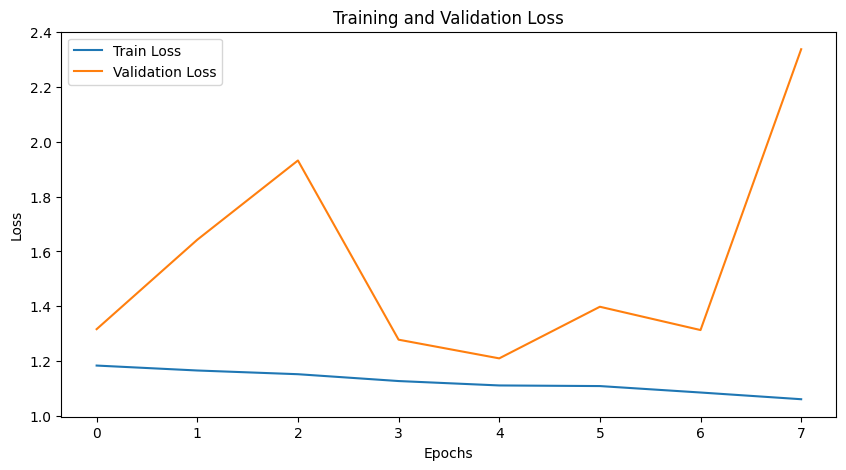

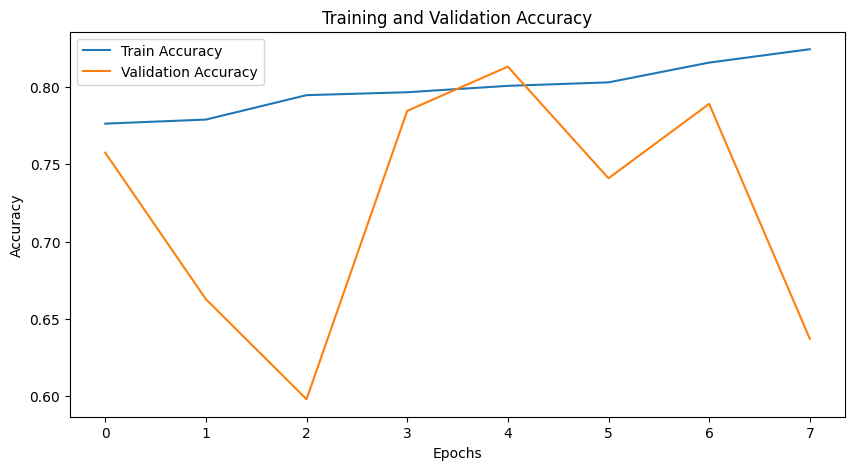

In [48]:
# Plot the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history_cnn_deep.history['loss'], label='Train Loss')
plt.plot(history_cnn_deep.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('train_validation_loss.png')
plt.show()

# Plot the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_cnn_deep.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn_deep.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('train_validation_accuracy.png')
plt.show()


In [49]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Generate predictions for the test dataset
y_pred = model_deep.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_one_hot, axis=1)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_true_classes, y_pred_classes)
print("Accuracy:", accuracy)

print("Confusion matrix:")
confusion_matrix = confusion_matrix(y_true_classes, y_pred_classes)
print(confusion_matrix)

print("\nClassification report:")
print(classification_report(y_true_classes, y_pred_classes))

# Print the accuracy and F1-score
print("\nAccuracy score:", accuracy_score(y_true_classes, y_pred_classes))
print("F1 score:", f1_score(y_true_classes, y_pred_classes, average='weighted'))

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
Accuracy: 0.7807228915662651
Confusion matrix:
[[205  26   0  10]
 [ 55 137  24  32]
 [  4  12  69   9]
 [  6   3   1 237]]

Classification report:
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       241
           1       0.77      0.55      0.64       248
           2       0.73      0.73      0.73        94
           3       0.82      0.96      0.89       247

    accuracy                           0.78       830
   macro avg       0.77      0.77      0.77       830
weighted avg       0.78      0.78      0.77       830


Accuracy score: 0.7807228915662651
F1 score: 0.771945866730296


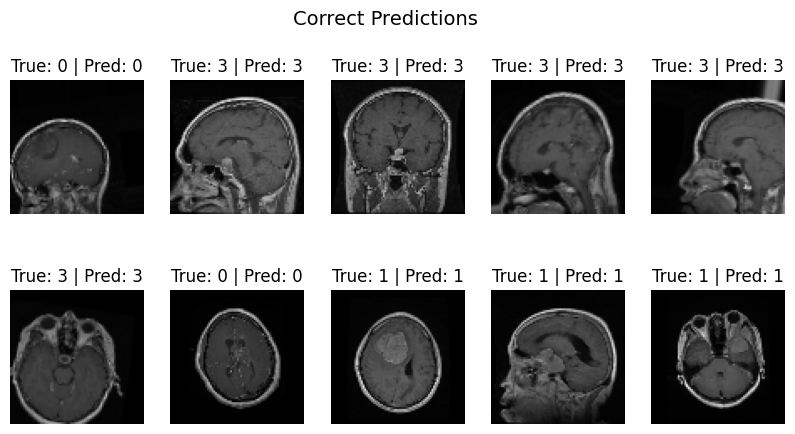

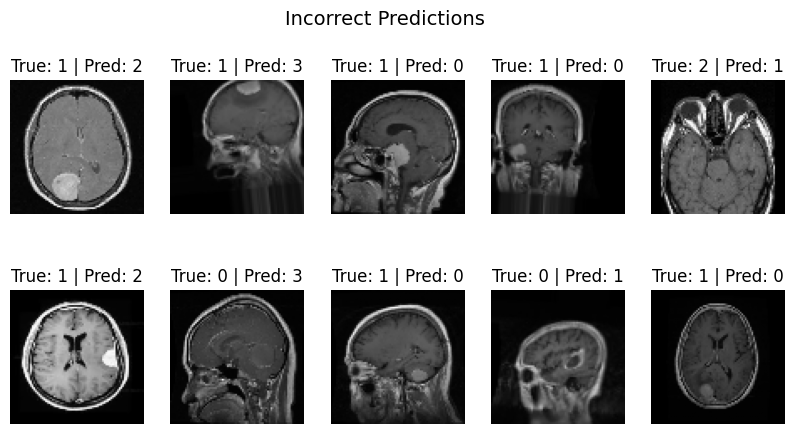

In [50]:
correct_indices = np.where(y_true_classes == y_pred_classes)[0]
incorrect_indices = np.where(y_true_classes != y_pred_classes)[0]

# Visualize correct predictions
plt.figure(figsize=(10, 5))
for i, idx in enumerate(correct_indices[:10]):  # Show 10 correct predictions
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx])
    plt.title(f"True: {y_true_classes[idx]} | Pred: {y_pred_classes[idx]}")
    plt.axis('off')
plt.suptitle("Correct Predictions", fontsize=14)
plt.show()

# Visualize incorrect predictions
plt.figure(figsize=(10, 5))
for i, idx in enumerate(incorrect_indices[:10]):  # Show 10 incorrect predictions
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx])
    plt.title(f"True: {y_true_classes[idx]} | Pred: {y_pred_classes[idx]}")
    plt.axis('off')
plt.suptitle("Incorrect Predictions", fontsize=14)
plt.show()


In [51]:
## adam compiler
model_deep.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_deep.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 80, 80, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 80, 80, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 40, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,89

 Total params: 3,599,268 (13.73 MB)

 Trainable params: 3,598,372 (13.73 MB)

 Non-trainable params: 896 (3.50 KB)

In [52]:
epochs = 25
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Model checkpoint to save the best weights only
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

# Train the model
history_cnn_deep = model_deep.fit(
    X_train, y_train_one_hot,
    epochs=epochs,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, checkpoint]
)

# Save the final full model
model_deep.save('model_deep_full_adam.keras')


Epoch 1/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.6228 - loss: 1.6209 - val_accuracy: 0.6852 - val_loss: 1.5998
Epoch 2/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.6832 - loss: 1.2901 - val_accuracy: 0.7184 - val_loss: 1.2070
Epoch 3/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7142 - loss: 1.1648 - val_accuracy: 0.7771 - val_loss: 1.0360
Epoch 4/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7628 - loss: 1.0661 - val_accuracy: 0.7500 - val_loss: 1.0348
Epoch 5/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7688 - loss: 1.0139 - val_accuracy: 0.7666 - val_loss: 1.0076
Epoch 6/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7786 - loss: 0.9375 - val_accuracy: 0.7786 - val_loss: 0.9768
Epoch 7/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7949 - loss: 0.9266 - val_accuracy: 0.7726 - val_loss: 1.0375
Epoch 8/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8183 - loss: 0.8600 - val_accuracy: 0.7711 -

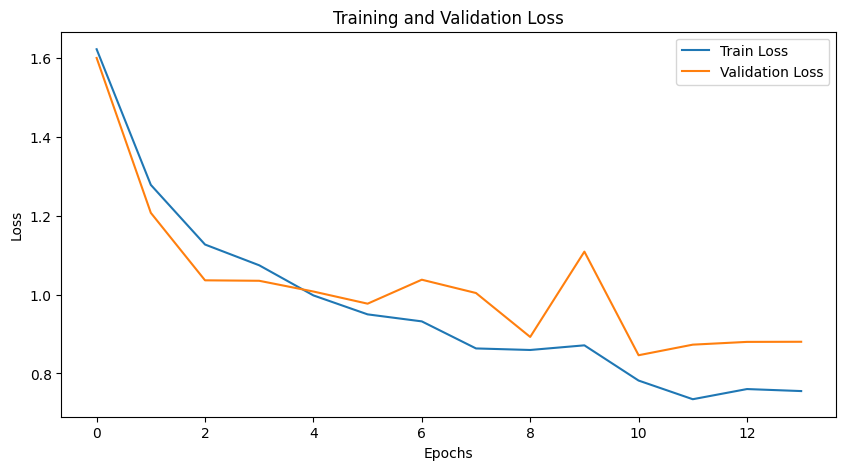

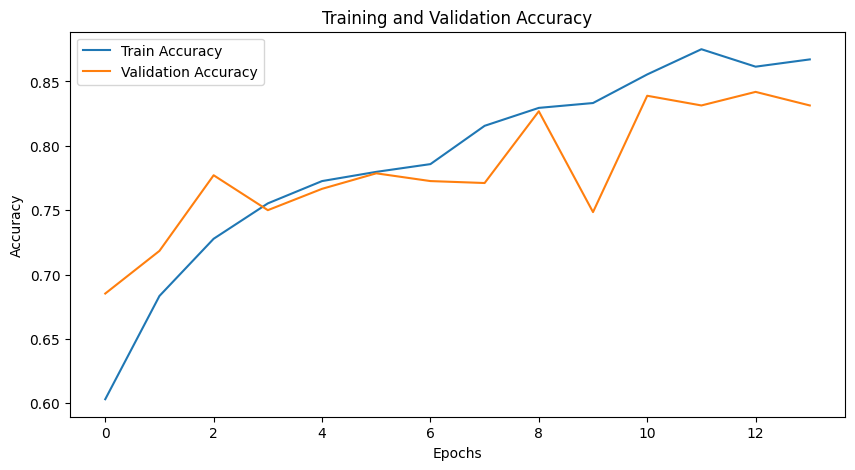

In [53]:
# Plot the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history_cnn_deep.history['loss'], label='Train Loss')
plt.plot(history_cnn_deep.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('train_validation_loss.png')
plt.show()

# Plot the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_cnn_deep.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn_deep.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('train_validation_accuracy.png')
plt.show()

In [54]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Generate predictions for the test dataset
y_pred = model_deep.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_one_hot, axis=1)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_true_classes, y_pred_classes)
print("Accuracy:", accuracy)

print("Confusion matrix:")
confusion_matrix = confusion_matrix(y_true_classes, y_pred_classes)
print(confusion_matrix)

print("\nClassification report:")
print(classification_report(y_true_classes, y_pred_classes))

# Print the accuracy and F1-score
print("\nAccuracy score:", accuracy_score(y_true_classes, y_pred_classes))
print("F1 score:", f1_score(y_true_classes, y_pred_classes, average='weighted'))

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
Accuracy: 0.8325301204819278
Confusion matrix:
[[207  28   0   6]
 [ 32 163  32  21]
 [  3   5  84   2]
 [  2   5   3 237]]

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85       241
           1       0.81      0.66      0.73       248
           2       0.71      0.89      0.79        94
           3       0.89      0.96      0.92       247

    accuracy                           0.83       830
   macro avg       0.81      0.84      0.82       830
weighted avg       0.83      0.83      0.83       830


Accuracy score: 0.8325301204819278
F1 score: 0.829090380389509


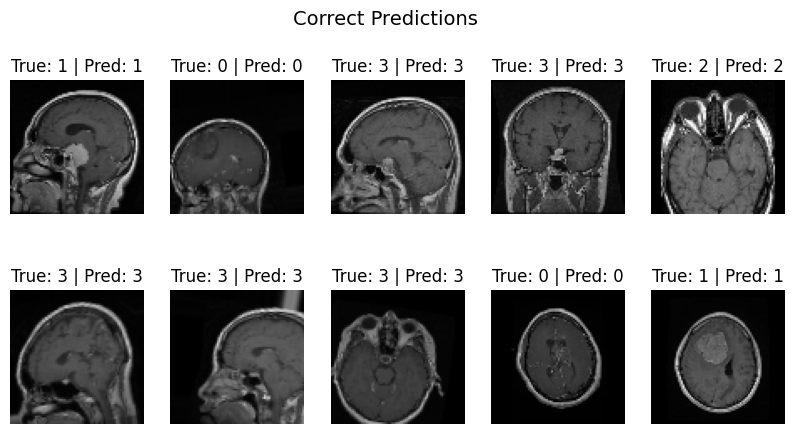

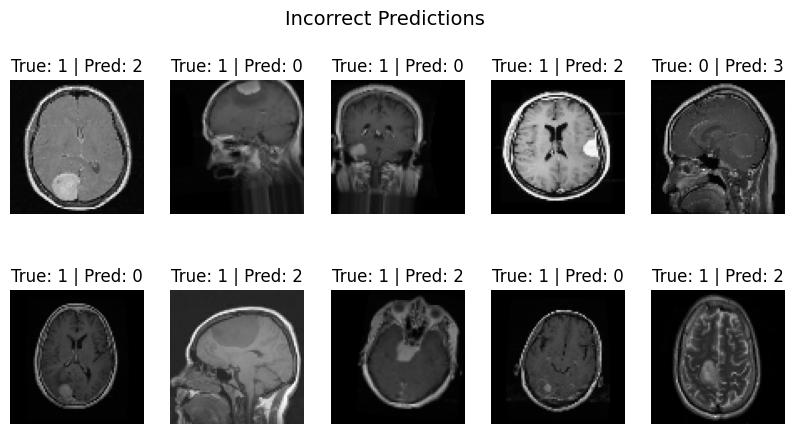

In [55]:
correct_indices = np.where(y_true_classes == y_pred_classes)[0]
incorrect_indices = np.where(y_true_classes != y_pred_classes)[0]

# Visualize correct predictions
plt.figure(figsize=(10, 5))
for i, idx in enumerate(correct_indices[:10]):  # Show 10 correct predictions
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx])
    plt.title(f"True: {y_true_classes[idx]} | Pred: {y_pred_classes[idx]}")
    plt.axis('off')
plt.suptitle("Correct Predictions", fontsize=14)
plt.show()

# Visualize incorrect predictions
plt.figure(figsize=(10, 5))
for i, idx in enumerate(incorrect_indices[:10]):  # Show 10 incorrect predictions
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx])
    plt.title(f"True: {y_true_classes[idx]} | Pred: {y_pred_classes[idx]}")
    plt.axis('off')
plt.suptitle("Incorrect Predictions", fontsize=14)
plt.show()

In [69]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
import tensorflow as tf
tf.random.set_seed(666)


# Match this to your actual input data shape
input_size = 80
input_shape = (input_size, input_size, 3)

# Load Xception base model
base_model = Xception(include_top=False, input_shape=input_shape, weights='imagenet')



In [70]:
# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dense(4, activation='softmax')(x)

# Create and compile the full model
transfer_learning_model = Model(inputs=base_model.input, outputs=x)
transfer_learning_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [72]:
history_Xception = transfer_learning_model.fit(
    X_train, y_train_one_hot,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# Evaluate on test set
loss, accuracy = transfer_learning_model.evaluate(X_test, y_test_one_hot, verbose=0)
print("Test loss:", loss)
print("Test accuracy:", accuracy)


Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9498 - loss: 0.1496 - val_accuracy: 0.7982 - val_loss: 0.6650
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9443 - loss: 0.1499 - val_accuracy: 0.8087 - val_loss: 0.5628
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9637 - loss: 0.1032 - val_accuracy: 0.7967 - val_loss: 0.6572
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9707 - loss: 0.0882 - val_accuracy: 0.8163 - val_loss: 0.6428
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9755 - loss: 0.0733 - val_accuracy: 0.8223 - val_loss: 0.6234
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9891 - loss: 0.0518 - val_accuracy: 0.8178 - val_loss: 0.6805
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9887 - loss: 0.0496 - val_accuracy: 0.8117 - val_loss: 0.6616
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9877 - loss: 0.0466 - val_accuracy: 0.8163 - v

In [80]:
transfer_learning_model.save('model_Xception_full.h5')

In [73]:
# Predictions
y_pred = transfer_learning_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_one_hot, axis=1)

# Metrics
print("Confusion matrix:")
print(confusion_matrix(y_test_classes, y_pred_classes))

print("\nClassification report:")
print(classification_report(y_test_classes, y_pred_classes))

print("\nAccuracy score:", accuracy_score(y_test_classes, y_pred_classes))
print("F1 score:", f1_score(y_test_classes, y_pred_classes, average='weighted'))


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Confusion matrix:
[[205  28   5   3]
 [ 30 190  11  17]
 [  2   7  82   3]
 [  3  25   4 215]]

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       241
           1       0.76      0.77      0.76       248
           2       0.80      0.87      0.84        94
           3       0.90      0.87      0.89       247

    accuracy                           0.83       830
   macro avg       0.83      0.84      0.83       830
weighted avg       0.83      0.83      0.83       830


Accuracy score: 0.8337349397590361
F1 score: 0.8341034881487944


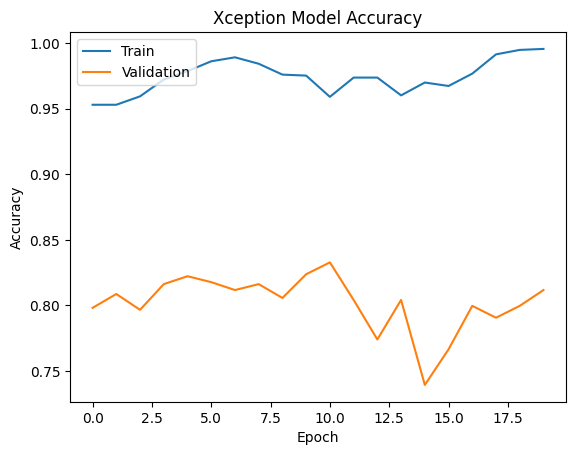

In [74]:
# Plot accuracy
plt.plot(history_Xception.history['accuracy'])
plt.plot(history_Xception.history['val_accuracy'])
plt.title('Xception Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

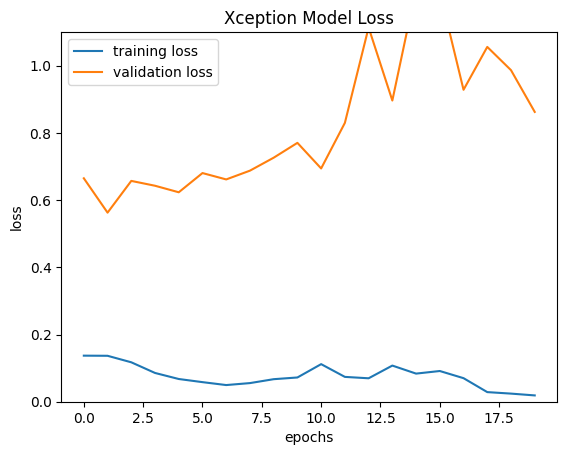

In [75]:
# Plot loss
plt.plot(history_Xception.history['loss'], label='training loss')
plt.plot(history_Xception.history['val_loss'], label='validation loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.ylim(0,1.1)
plt.title('Xception Model Loss')
plt.show()

In [77]:
# Extract the validation accuracy of the last epoch for each model
val_acc_fcn = history_fcn.history['val_accuracy'][-1]
val_acc_cnn = history_cnn_deep.history['val_accuracy'][-1]
val_acc_Xception = history_Xception.history['val_accuracy'][-1]

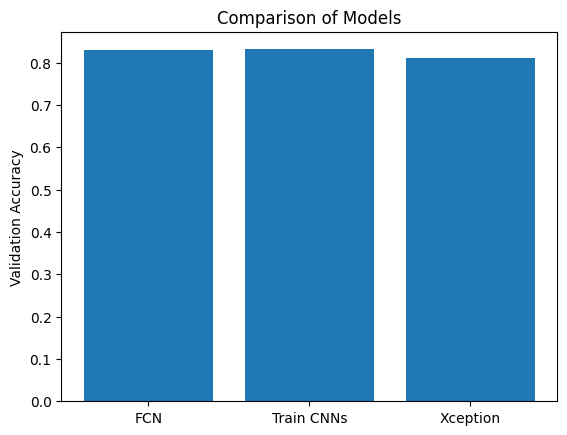

In [78]:
# Compare with other models
val_acc_Xception = history_Xception.history['val_accuracy'][-1]
models = ['FCN','Train CNNs', 'Xception']
val_accs = [val_acc_fcn, val_acc_cnn, val_acc_Xception]

fig, ax = plt.subplots()
ax.bar(models, val_accs)
ax.set_ylabel('Validation Accuracy')
ax.set_title('Comparison of Models')
plt.show()

Saving image(91).jpg to image(91).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted class: meningioma_tumor
Prediction probabilities: [5.2721407e-05 9.9994147e-01 2.4231255e-07 5.6116801e-06]


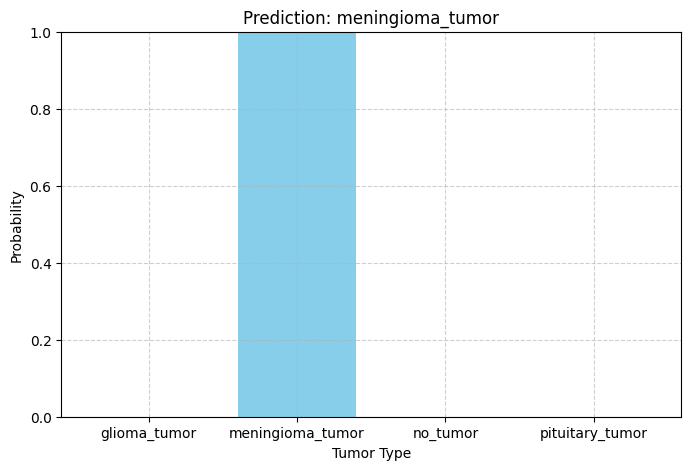

In [84]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import cv2

# Step 1: Upload Image
uploaded = files.upload()

# Step 2: Load and preprocess the image
img_path = list(uploaded.keys())[0]
img = load_img(img_path, target_size=(80, 80))  # Match the size you used for training
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = preprocess_input(img_array)  # Preprocess for Xception

# Step 3: Predict
predictions = transfer_learning_model.predict(img_array)
predicted_class = np.argmax(predictions[0])
class_labels = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

# Step 4: Display prediction
print("Predicted class:", class_labels[predicted_class])
print("Prediction probabilities:", predictions[0])

# Step 5: Plot bar chart
plt.figure(figsize=(8,5))
plt.bar(class_labels, predictions[0], color='skyblue')
plt.xlabel('Tumor Type')
plt.ylabel('Probability')
plt.title(f'Prediction: {class_labels[predicted_class]}')
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
